<a href="https://colab.research.google.com/github/Luke-Dev-Tech/CNN_Animal_Species_Recognition/blob/main/Animal_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [1] Kaggle Json

In [41]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!mkdir -p modular # for the modular files

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


!mkdir -p modular

# [2] Moduler Section

## [2.1] kaggle_data.py

In [42]:
%%writefile modular/kaggle_data.py
import os
import zipfile
from pathlib import Path
import subprocess

def kaggleDataImport():
    data_path  = Path("data")
    image_path = data_path / "animal_style_babe_10"

    data_path.mkdir(parents=True, exist_ok=True)

    # check folder exists AND is non-empty (guards against failed previous runs)
    if image_path.exists() and any(image_path.iterdir()):
        print(f"[Success] ===> {image_path} already exists.")
        return

    image_path.mkdir(parents=True, exist_ok=True)

    # reuse the zip if it's already downloaded, otherwise fetch it
    zip_files = list(data_path.glob("*.zip"))   # ← *.zip, not *

    if not zip_files:
        print("[Info]: Downloading from Kaggle...")
        subprocess.run(
            ["kaggle", "datasets", "download", "-d",
             "iamsouravbanerjee/animal-image-dataset-90-different-animals", "-p", str(data_path)],
            check=True
        )
        zip_files = list(data_path.glob("*.zip"))

    if not zip_files:
        raise FileNotFoundError("Download completed but no .zip found in data/")

    zip_file = zip_files[0]
    print(f"[Info]: Extracting {zip_file.name}...")

    with zipfile.ZipFile(zip_file, "r") as zf:
        zf.extractall(image_path)

    os.remove(zip_file)
    print(f"[Success]: Dataset ready at {image_path}")

Overwriting modular/kaggle_data.py


## [2.2] Data_Setup (data_setup.py)

In [43]:
%%writefile modular/data_setup.py

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import os
import torch
import numpy as np

NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    data_dir: str,
    train_transform: transforms.Compose,
    test_transform: transforms.Compose,
    batch_size: int,
    test_size: float = 0.2,
    random_state: int = 42,
    num_workers: int = NUM_WORKERS,
    apply_weighted_sampler: bool = False
):
    train_data = datasets.ImageFolder(root=data_dir, transform=train_transform)
    test_data = datasets.ImageFolder(root=data_dir, transform=test_transform)

    class_names = train_data.classes
    indices = list(range(len(train_data)))

    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        shuffle=True,
        stratify=train_data.targets
    )

    train_dataset = Subset(train_data, train_idx)
    test_dataset = Subset(test_data, test_idx)

    print(f"[INFO] Total images: {len(train_data)}")
    print(f"[INFO] Training images: {len(train_dataset)}")
    print(f"[INFO] Testing images: {len(test_dataset)}")


    sampler = None
    if apply_weighted_sampler:
        print("[INFO] Applying WeightedRandomSampler for class imbalance...")
        train_labels = np.array(train_data.targets)[train_idx]

        class_counts = np.bincount(train_labels)
        class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
        sample_weights = class_weights[train_labels]

        sampler = torch.utils.data.WeightedRandomSampler(
            sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )
        train_dataloader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True,
            sampler=sampler
        )
    else:
        train_dataloader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=True
        )

    test_dataloader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return (train_dataloader, test_dataloader, class_names, train_dataset, test_dataset, train_idx, test_idx)

Overwriting modular/data_setup.py


## [2.3] Engine (Engine.py)

In [44]:
%%writefile modular/engine.py

import torch
from tqdm.auto import tqdm
from typing import Dict, List, Optional


def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fun: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fun(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    return train_loss / len(dataloader), train_acc / len(dataloader)


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fun: torch.nn.Module,
              device: torch.device):       # optimizer removed — test step never needs it
    model.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss = loss_fun(y_pred, y)
            test_loss += loss.item()
            test_acc += (torch.argmax(torch.softmax(y_pred, dim=1), dim=1) == y).sum().item() / len(y_pred)

    return test_loss / len(dataloader), test_acc / len(dataloader)


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fun: torch.nn.Module,
          epochs: int,
          device: torch.device,
          scheduler=None,          # NEW: pass your CosineAnnealingLR here
          early_stopping=None      # NEW: pass your EarlyStopping instance here
          ) -> Dict[str, List]:

    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fun, optimizer, device)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fun, device)

        # ---- Scheduler step (once per epoch, after optimiser step) ----
        current_lr = optimizer.param_groups[0]['lr']
        if scheduler is not None:
            scheduler.step()

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f} | "
            f"lr: {current_lr:.6f}"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        # ---- Early stopping check (after printing so you see the epoch) ----
        if early_stopping is not None:
            early_stopping(test_loss, model)
            if early_stopping.stop:
                print(f"\n[EarlyStopping] Triggered at epoch {epoch+1}. Best val_loss: {early_stopping.best_loss:.4f}")
                early_stopping.restore_best(model)   # reload the best weights
                break

    return results

Overwriting modular/engine.py


## [2.4] Save the model (utils.py)

In [45]:
%%writefile modular/utils.py

import torch
from pathlib import Path

def save_model(model: torch.nn.Module,
               target_dir: str,
               model_name:str):
  target_dir_path = Path(target_dir)
  target_dir_path.mkdir(parents=True, exist_ok=True)

  model_save_path = target_dir_path / model_name

  print(f"[INFO] Saving model to: {model_save_path}")
  torch.save(obj=model.state_dict(), f=model_save_path)

Overwriting modular/utils.py


## [2.5] Pred And Plot an individual Image

In [46]:
%%writefile modular/pred_and_plot_img.py
from typing import List, Tuple
import torch
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

device = 'cuda' if torch.cuda.is_available() else 'cpu'


def pred_and_plot_img(
    model: torch.nn.Module,
    image_path: str,
    class_name: List[str],
    image_size: Tuple[int, int] = (224, 224),
    transform: torchvision.transforms = None,
    device: torch.device = device
):
    # Load image
    img_pil = Image.open(image_path).convert("RGB")

    # Use provided transform or default VGG-Face transform
    if transform is None:
        transform = torchvision.transforms.Compose([
            torchvision.transforms.Resize(image_size),
            torchvision.transforms.Grayscale(num_output_channels=3),
            torchvision.transforms.ToTensor(),
            transforms.Normalize(
              mean=[0.485, 0.456, 0.406],
              std=[0.229, 0.224, 0.225]
          )
        ])

    model.to(device)
    model.eval()

    with torch.inference_mode():
        img_tensor = transform(img_pil).unsqueeze(0).to(device)
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        pred_prob = probs.max().item()

    actual_label = Path(image_path).parent.name
    pred_label = class_name[pred_idx]

    plt.figure(figsize=(5, 5))
    plt.imshow(img_pil)
    plt.title(
        f"Actual: {actual_label} | Pred: {pred_label} | Prob: {pred_prob:.3f}"
    )
    plt.axis("off")


Overwriting modular/pred_and_plot_img.py


# [2B] Early Stop

In [47]:
# ============================================================
# Early Stopping
# ============================================================
import torch
import numpy as np
import copy

class EarlyStopping:
    """
    Monitors val_loss each epoch.
    Saves best model weights when val_loss improves.
    Stops training if val_loss hasn't improved for `patience` epochs.
    Restores best weights at the end.

    Parameters
    ----------
    patience : int
        How many epochs to wait after last improvement before stopping.
    min_delta : float
        Minimum change in val_loss to count as an improvement.
        Prevents stopping on tiny, noise-level improvements.
    verbose : bool
        Whether to print messages when saving or about to stop.
    """

    def __init__(self, patience: int = 5, min_delta: float = 1e-4, verbose: bool = True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose

        self.best_loss  = np.inf      # track the lowest val_loss seen
        self.counter    = 0           # epochs without improvement
        self.stop       = False       # flag checked by train loop
        self.best_state = None        # saved model weights at best epoch

    def __call__(self, val_loss: float, model: torch.nn.Module):
        """Called once per epoch with the current val_loss and model."""

        if val_loss < self.best_loss - self.min_delta:
            # Improvement found — save the weights and reset counter
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = copy.deepcopy(model.state_dict())
            if self.verbose:
                print(f"  [EarlyStopping] ✓ val_loss improved to {val_loss:.4f} — model saved")
        else:
            # No improvement
            self.counter += 1
            if self.verbose:
                print(f"  [EarlyStopping] No improvement ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.stop = True

    def restore_best(self, model: torch.nn.Module):
        """Load the best saved weights back into the model."""
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
            print(f"  [EarlyStopping] Best weights restored (val_loss: {self.best_loss:.4f})")

# [3] Pipeline

## Import and Attributes

In [48]:
import os
import torch
import importlib
from modular import kaggle_data, data_setup, engine, utils, pred_and_plot_img
import torchvision.transforms as transforms
import torchvision
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── force Python to re-read the .py files you just wrote ──
importlib.reload(kaggle_data)
importlib.reload(data_setup)
importlib.reload(engine)
importlib.reload(utils)
# -----------------------------------------------------------
kaggle_data.kaggleDataImport()


[Success] ===> data/animal_style_babe_10 already exists.


## Transform Obj construction

In [49]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),                                   # wider rotation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),        # slight position shift
    transforms.ColorJitter(brightness=0.3, contrast=0.3),            # MUST be before Grayscale
    # transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Data Setup with Dataloader

In [50]:
#=================Attribute Section===========================
# NUM_EPOCHS = 30
BATCH_SIZE = 32
# HIDDEN_UNITS = 10
# LEARNING_RATE = 0.0005
data_dir = "data/animal_style_babe_10/animals/animals"
#=============================================================

train_dataloader, test_dataloader, class_names , train_dataset, test_dataset, train_index, test_index = data_setup.create_dataloaders(
  data_dir=data_dir,
  train_transform=train_transform,
  test_transform=test_transform,
  batch_size=BATCH_SIZE,
  test_size=0.2,  # 80/20 split
  apply_weighted_sampler=True
)
#=============================================================

[INFO] Total images: 5400
[INFO] Training images: 4320
[INFO] Testing images: 1080
[INFO] Applying WeightedRandomSampler for class imbalance...


## Calling Engine While Timing

In [51]:
from modular import engine
from timeit import default_timer as timer
def engine_with_time_count(model, train_dataloader, test_dataloader,
                            loss_fun, optimizer, epoch_num, device,
                            scheduler=None, early_stopping=None):
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)
    start_time = timer()
    engine.train(
        model=model,
        train_dataloader=train_dataloader,
        test_dataloader=test_dataloader,
        loss_fun=loss_fun,
        optimizer=optimizer,
        epochs=epoch_num,
        device=device,
        scheduler=scheduler,
        early_stopping=early_stopping
    )
    end_time = timer()
    print(f"[INFO] Total training time: {end_time - start_time:.3f} seconds")

## EfficientNet B2 Model construction

In [52]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
from collections import Counter

#=======================EfficientNet B2 Model============================#
weigths = torchvision.models.EfficientNet_B2_Weights.DEFAULT
model = torchvision.models.efficientnet_b2(weights=weigths).to(device)

num_classes = len(class_names)
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.3, inplace=True),
    torch.nn.Linear(in_features=1408, out_features=num_classes, bias=True)
).to(device)
#=============================================================



## Loss Function and Class Inbalance Handling

In [53]:
from collections import Counter

# Class inblance handling with class weight
# Access the original dataset's targets through the Subset, then filter by the Subset's indices
counts = Counter([train_dataloader.dataset.dataset.targets[i] for i in train_dataloader.dataset.indices])
total_samples = sum(counts.values())

# Weight = inverse frequency. Rare classes get higher weight.
class_weights = torch.tensor(
    [total_samples / counts[i] for i in range(len(class_names))],
    dtype=torch.float
).to(device)

print("Class weights:")
for name, w in zip(class_names, class_weights):
    print(f"  {name}: {w:.3f}")
#=============================================================
loss_fun = torch.nn.CrossEntropyLoss(weight=class_weights)

Class weights:
  antelope: 90.000
  badger: 90.000
  bat: 90.000
  bear: 90.000
  bee: 90.000
  beetle: 90.000
  bison: 90.000
  boar: 90.000
  butterfly: 90.000
  cat: 90.000
  caterpillar: 90.000
  chimpanzee: 90.000
  cockroach: 90.000
  cow: 90.000
  coyote: 90.000
  crab: 90.000
  crow: 90.000
  deer: 90.000
  dog: 90.000
  dolphin: 90.000
  donkey: 90.000
  dragonfly: 90.000
  duck: 90.000
  eagle: 90.000
  elephant: 90.000
  flamingo: 90.000
  fly: 90.000
  fox: 90.000
  goat: 90.000
  goldfish: 90.000
  goose: 90.000
  gorilla: 90.000
  grasshopper: 90.000
  hamster: 90.000
  hare: 90.000
  hedgehog: 90.000
  hippopotamus: 90.000
  hornbill: 90.000
  horse: 90.000
  hummingbird: 90.000
  hyena: 90.000
  jellyfish: 90.000
  kangaroo: 90.000
  koala: 90.000
  ladybugs: 90.000
  leopard: 90.000
  lion: 90.000
  lizard: 90.000
  lobster: 90.000
  mosquito: 90.000
  moth: 90.000
  mouse: 90.000
  octopus: 90.000
  okapi: 90.000
  orangutan: 90.000
  otter: 90.000
  owl: 90.000
  ox:

In [54]:
#=========================={PHASE 1}===============================#
# PHASE (1): Backbone
# EPOCH - 5
# LR - 0.001
# Backbone
# New optimizer [Mandatory]
# Weight decay [ADDed]
#=============================================================
# Backbone phase: Freze all the hidden layers
for param in model.features.parameters():
    param.requires_grad = False

#====================Phase 1 Optimizer and scheduler========================
optimizer_p1 = torch.optim.Adam(model.classifier.parameters(), lr=0.001)

# Scheduler
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1,
    T_max=15,
    eta_min=1e-6
)

# Early Stopping - From EarlyStopping Class
early_stopping_p1 = EarlyStopping(patience=5, min_delta=1e-4, verbose=True)
#=============================================================
print("======== PHASE 1: Training ==========")
engine_with_time_count(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fun=loss_fun,
    optimizer=optimizer_p1,
    epoch_num=15,           # max epochs — may stop earlier
    device=device,
    scheduler=scheduler_p1,
    early_stopping=early_stopping_p1
)
print("=======================================")
#=============================================================

======== PHASE 1: Training ==========


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.6767 | train_acc: 0.5873 | test_loss: 1.4952 | test_acc: 0.8165 | lr: 0.001000
  [EarlyStopping] ✓ val_loss improved to 1.4952 — model saved
Epoch: 2 | train_loss: 1.0459 | train_acc: 0.8336 | test_loss: 0.8465 | test_acc: 0.8511 | lr: 0.000989
  [EarlyStopping] ✓ val_loss improved to 0.8465 — model saved
Epoch: 3 | train_loss: 0.7340 | train_acc: 0.8562 | test_loss: 0.6711 | test_acc: 0.8673 | lr: 0.000957
  [EarlyStopping] ✓ val_loss improved to 0.6711 — model saved
Epoch: 4 | train_loss: 0.5701 | train_acc: 0.8829 | test_loss: 0.5736 | test_acc: 0.8738 | lr: 0.000905
  [EarlyStopping] ✓ val_loss improved to 0.5736 — model saved
Epoch: 5 | train_loss: 0.5005 | train_acc: 0.8958 | test_loss: 0.5078 | test_acc: 0.8796 | lr: 0.000835
  [EarlyStopping] ✓ val_loss improved to 0.5078 — model saved
Epoch: 6 | train_loss: 0.4501 | train_acc: 0.9023 | test_loss: 0.4841 | test_acc: 0.8805 | lr: 0.000750
  [EarlyStopping] ✓ val_loss improved to 0.4841 — model saved
Epoc

# Phase 2 [-1]

In [55]:
# #======================={PHASE 2}============================#
# # PHASE (2): Fine-Tuning (last 1 block )
# # EPOCH - 12
# # LR - 0.0001
# # Unfreeze last block
# # New optimizer [Mandatory]
# # Weight decay [ADDed]
# # Phase 2: Model slightly adapts high-level facial features (hopefully)
# #=============================================================
# # Fine Tuning Level: Unfreeze one layer
#======================={PHASE 2}============================#
# Unfreeze last backbone block for fine-tuning
for param in model.features[-1:].parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,         # 10x lower than Phase 1 — protects pretrained weights
    weight_decay=1e-4
)

scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=10, eta_min=1e-7
)

# Fresh early stopping instance for Phase 2
early_stopping_p2 = EarlyStopping(patience=5, min_delta=1e-4, verbose=True)

print("======== PHASE 2: Fine-Tuning Last Block ==========")
engine_with_time_count(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fun=loss_fun,
    optimizer=optimizer_p2,
    epoch_num=10,
    device=device,
    scheduler=scheduler_p2,
    early_stopping=early_stopping_p2
)
print("====================================================")

======== PHASE 2: Fine-Tuning Last Block ==========


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.1789 | train_acc: 0.9701 | test_loss: 0.4077 | test_acc: 0.8915 | lr: 0.000100
  [EarlyStopping] ✓ val_loss improved to 0.4077 — model saved
Epoch: 2 | train_loss: 0.1795 | train_acc: 0.9741 | test_loss: 0.3927 | test_acc: 0.8961 | lr: 0.000098
  [EarlyStopping] ✓ val_loss improved to 0.3927 — model saved
Epoch: 3 | train_loss: 0.1800 | train_acc: 0.9706 | test_loss: 0.3896 | test_acc: 0.8952 | lr: 0.000090
  [EarlyStopping] ✓ val_loss improved to 0.3896 — model saved
Epoch: 4 | train_loss: 0.1637 | train_acc: 0.9782 | test_loss: 0.3826 | test_acc: 0.8961 | lr: 0.000079
  [EarlyStopping] ✓ val_loss improved to 0.3826 — model saved
Epoch: 5 | train_loss: 0.1606 | train_acc: 0.9755 | test_loss: 0.3683 | test_acc: 0.8989 | lr: 0.000065
  [EarlyStopping] ✓ val_loss improved to 0.3683 — model saved
Epoch: 6 | train_loss: 0.1612 | train_acc: 0.9771 | test_loss: 0.3728 | test_acc: 0.8961 | lr: 0.000050
  [EarlyStopping] No improvement (1/5)
Epoch: 7 | train_loss: 0.15

In [56]:
#======================={PHASE 3}============================#
# Unfreeze last 3 blocks instead of just 1
for param in model.features[-3:].parameters():
    param.requires_grad = True

optimizer_p3 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.00001,        # even lower — more blocks unfrozen = more risk of destroying weights
    weight_decay=1e-4
)

scheduler_p3 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p3, T_max=15, eta_min=1e-8
)

early_stopping_p3 = EarlyStopping(patience=5, min_delta=1e-4, verbose=True)

print("======== PHASE 3: Deeper Fine-Tuning ==========")
engine_with_time_count(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fun=loss_fun,
    optimizer=optimizer_p3,
    epoch_num=15,
    device=device,
    scheduler=scheduler_p3,
    early_stopping=early_stopping_p3
)
print("================================================")

======== PHASE 3: Deeper Fine-Tuning ==========


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.0837 | train_acc: 0.9919 | test_loss: 0.3547 | test_acc: 0.9017 | lr: 0.000010
  [EarlyStopping] ✓ val_loss improved to 0.3547 — model saved
Epoch: 2 | train_loss: 0.0785 | train_acc: 0.9938 | test_loss: 0.3408 | test_acc: 0.9026 | lr: 0.000010
  [EarlyStopping] ✓ val_loss improved to 0.3408 — model saved
Epoch: 3 | train_loss: 0.0792 | train_acc: 0.9914 | test_loss: 0.3398 | test_acc: 0.8998 | lr: 0.000010
  [EarlyStopping] ✓ val_loss improved to 0.3398 — model saved
Epoch: 4 | train_loss: 0.0727 | train_acc: 0.9931 | test_loss: 0.3390 | test_acc: 0.9053 | lr: 0.000009
  [EarlyStopping] ✓ val_loss improved to 0.3390 — model saved
Epoch: 5 | train_loss: 0.0744 | train_acc: 0.9910 | test_loss: 0.3252 | test_acc: 0.9072 | lr: 0.000008
  [EarlyStopping] ✓ val_loss improved to 0.3252 — model saved
Epoch: 6 | train_loss: 0.0771 | train_acc: 0.9900 | test_loss: 0.3278 | test_acc: 0.9044 | lr: 0.000008
  [EarlyStopping] No improvement (1/5)
Epoch: 7 | train_loss: 0.07

In [57]:
#======================={PHASE 4}============================#
# Unfreeze last 5 blocks — going deeper into the backbone
for param in model.features[-5:].parameters():
    param.requires_grad = True

optimizer_p4 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.000005,       # lower than Phase 3 — more blocks = more risk
    weight_decay=1e-4
)

scheduler_p4 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p4, T_max=15, eta_min=1e-8
)

early_stopping_p4 = EarlyStopping(patience=5, min_delta=1e-4, verbose=True)

print("======== PHASE 4: Deeper Fine-Tuning ==========")
engine_with_time_count(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fun=loss_fun,
    optimizer=optimizer_p4,
    epoch_num=15,
    device=device,
    scheduler=scheduler_p4,
    early_stopping=early_stopping_p4
)
print("================================================")

======== PHASE 4: Deeper Fine-Tuning ==========


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.0278 | train_acc: 0.9984 | test_loss: 0.3181 | test_acc: 0.9099 | lr: 0.000005
  [EarlyStopping] ✓ val_loss improved to 0.3181 — model saved
Epoch: 2 | train_loss: 0.0294 | train_acc: 0.9993 | test_loss: 0.3077 | test_acc: 0.9136 | lr: 0.000005
  [EarlyStopping] ✓ val_loss improved to 0.3077 — model saved
Epoch: 3 | train_loss: 0.0294 | train_acc: 0.9986 | test_loss: 0.3121 | test_acc: 0.9145 | lr: 0.000005
  [EarlyStopping] No improvement (1/5)
Epoch: 4 | train_loss: 0.0297 | train_acc: 0.9993 | test_loss: 0.3145 | test_acc: 0.9145 | lr: 0.000005
  [EarlyStopping] No improvement (2/5)
Epoch: 5 | train_loss: 0.0316 | train_acc: 0.9991 | test_loss: 0.3024 | test_acc: 0.9173 | lr: 0.000004
  [EarlyStopping] ✓ val_loss improved to 0.3024 — model saved
Epoch: 6 | train_loss: 0.0331 | train_acc: 0.9991 | test_loss: 0.3053 | test_acc: 0.9145 | lr: 0.000004
  [EarlyStopping] No improvement (1/5)
Epoch: 7 | train_loss: 0.0350 | train_acc: 0.9975 | test_loss: 0.3023 | t

KeyboardInterrupt: 

In [ ]:
#======================={PHASE 5}============================#
# Unfreeze everything — full model fine-tuning
for param in model.parameters():
    param.requires_grad = True

optimizer_p5 = torch.optim.Adam(
    model.parameters(),
    lr=0.000001,       # very low — entire backbone is exposed
    weight_decay=1e-4
)

scheduler_p5 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p5, T_max=15, eta_min=1e-9
)

early_stopping_p5 = EarlyStopping(patience=5, min_delta=1e-4, verbose=True)

print("======== PHASE 5: Full Model Fine-Tuning ==========")
engine_with_time_count(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fun=loss_fun,
    optimizer=optimizer_p5,
    epoch_num=20,
    device=device,
    scheduler=scheduler_p5,
    early_stopping=early_stopping_p5
)
print("==================================================")

# [4] Saving Model

In [ ]:
#=================Utils for saving models=====================
utils.save_model(
    model=model,
    target_dir='models',
    model_name=f'Animals_Classifier.pth'
)
#=============================================================

# [5] Random 3 IMG Testing

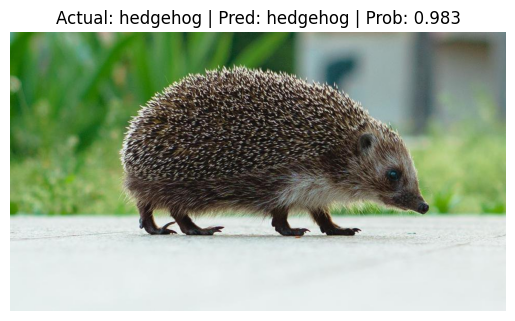

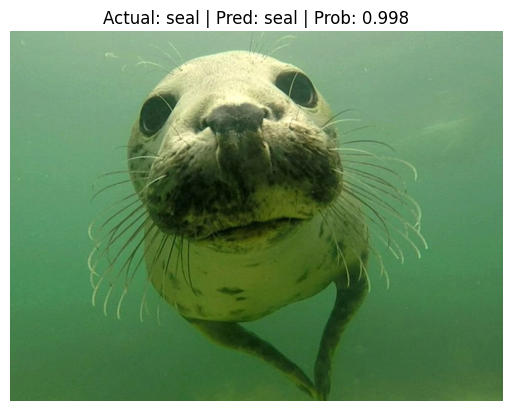

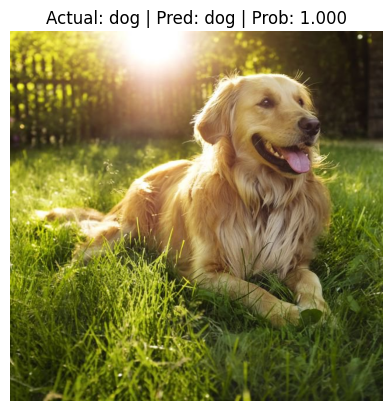

In [58]:
from typing import List, Tuple
import torch
import torchvision
import matplotlib.pyplot as plt
from PIL import Image # Import Image for PIL operations
from pathlib import Path # Import Path to handle paths


def pred_and_plot_img(model: torch.nn.Module,
                      image_path:str,
                      class_name: List[str],
                      image_size: Tuple[int, int] = (224, 224),
                      transform: torchvision.transforms = None,
                      device: torch.device = device):
  # Load image as PIL Image first
  img_pil = Image.open(image_path).convert("RGB") # Ensure it's RGB

  if transform is not None:
    img_transform = transform
  else:
    img_transform = torchvision.transforms.Compose([
        torchvision.transforms.Resize(image_size),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
  model.to(device)
  model.eval()
  with torch.inference_mode():
    # Apply transform to the PIL image
    transformed_img = img_transform(img_pil).unsqueeze(dim=0) # this is adding a batch size (1 img)
    target_image_pred = model(transformed_img.to(device))
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1) # sigmoid
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1) # return index

    # Extract actual label from image_path
    actual_label = Path(image_path).parent.name

    plt.figure()
    # To plot, convert the PIL image to a tensor (without normalization, just to display original appearance)
    img_tensor_for_plot = torchvision.transforms.ToTensor()(img_pil)
    plt.imshow(img_tensor_for_plot.permute(1, 2, 0)) # Permute to HWC for matplotlib
    plt.title(f"Actual: {actual_label} | Pred: {class_name[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False)



import random
num_images_to_plot = 3
test_dir = data_dir
test_image_paths = list(Path(test_dir).glob("*/*.jpg"))
random_image_paths = random.sample(test_image_paths, k=num_images_to_plot)

for image_path in random_image_paths:
  pred_and_plot_img(
      model=model,
      image_path=image_path,
      class_name=class_names,
      transform=test_transform,
      device=device
  )

# [6] Custom IMG TESTing

In [59]:
import requests
import time
import random
from pathlib import Path
from urllib.parse import urlparse

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".gif", ".webp", ".bmp", ".tiff", ".svg"}

def custom_img_testing(
    link: str,
    output_dir: str = "data",
    retries: int = 3,
    timeout: int = 10,
) -> Path:
    """
    Download an image from a URL robustly.

    Args:
        link:       URL of the image to download.
        output_dir: Directory to save the image in.
        retries:    Number of download attempts before giving up.
        timeout:    Request timeout in seconds.

    Returns:
        Path to the downloaded (or pre-existing) image file.

    Raises:
        ValueError: If the URL is invalid or the response is not an image.
        RuntimeError: If all download attempts fail.
    """
    parsed = urlparse(link)
    if not parsed.scheme or not parsed.netloc:
        raise ValueError(f"Invalid URL: '{link}' — must include scheme (http/https) and host.")

    url_ext = Path(parsed.path).suffix.lower()
    ext = url_ext if url_ext in SUPPORTED_EXTENSIONS else ".jpg"

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    img_path = output_dir / f"custom_img_{round(random.random(), 3)}{ext}"

    if img_path.is_file():
        print(f"Already exists: {img_path}")
        return img_path

    headers = {"User-Agent": "Mozilla/5.0 (compatible; ImageDownloader/1.0)"}
    last_exc = None

    for attempt in range(1, retries + 1):
        try:
            print(f"Downloading image (attempt {attempt}/{retries}) ...")
            response = requests.get(link, headers=headers, timeout=timeout, stream=True)
            response.raise_for_status()

            content_type = response.headers.get("Content-Type", "")
            if not content_type.startswith("image/"):
                raise ValueError(
                    f"URL did not return an image. "
                    f"Got Content-Type: '{content_type}'"
                )

            if url_ext not in SUPPORTED_EXTENSIONS:
                mime_ext = "." + content_type.split("/")[-1].split(";")[0].strip()
                if mime_ext in SUPPORTED_EXTENSIONS:
                    img_path = img_path.with_suffix(mime_ext)

            with open(img_path, "wb") as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)

            print(f"Saved to: {img_path}")
            return img_path

        except (requests.RequestException, OSError) as exc:
            last_exc = exc
            if attempt < retries:
                wait = 2 ** (attempt - 1)  # 1s, 2s, 4s, ...
                print(f"Attempt {attempt} failed ({exc}). Retrying in {wait}s ...")
                time.sleep(wait)

    raise RuntimeError(
        f"Failed to download image after {retries} attempts. "
        f"Last error: {last_exc}"
    ) from last_exc

Saved to: data/custom_img_0.54.jpg


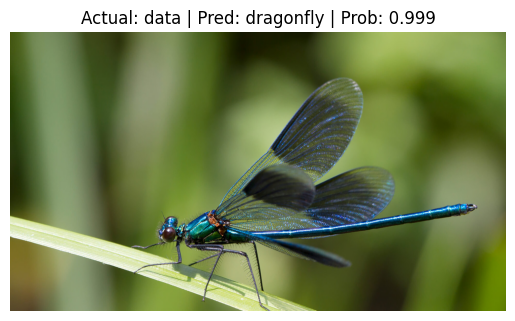

In [60]:
pred_and_plot_img(
    model=model,
    image_path=custom_img_testing(link="https://animals.sandiegozoo.org/sites/default/files/2016-10/animals_hero_dragonfly.jpg"),
    class_name=class_names,
    transform=test_transform,
    device=device
)

Saved to: data/custom_img_0.146.jpg


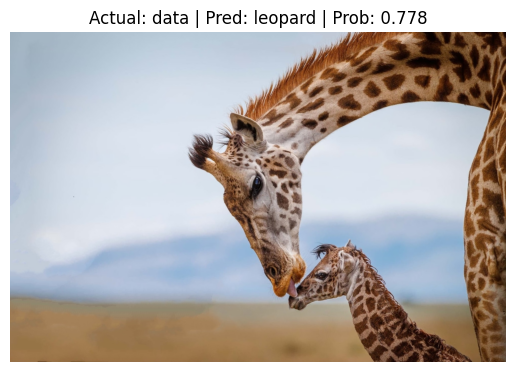

In [61]:
pred_and_plot_img(
    model=model,
    image_path=custom_img_testing(link="https://cms.bbcearth.com/sites/default/files/factfiles/2024-04/Giraffe_BBC%20Earth%20Factfiles%205.jpg?imwidth=1920"),
    class_name=class_names,
    transform=test_transform,
    device=device
)

In [62]:
y_true = []
y_pred = []

model.eval()
with torch.inference_mode():
  for X, y in test_dataloader:
    X, y = X.to(device), y.to(device)

    # Forward pass
    logits = model(X)

    # Convert logits to predicted labels
    predicted_labels = torch.argmax(torch.softmax(logits, dim=1), dim=1)

    # Store true and predicted labels
    y_true.extend(y.cpu().numpy())
    y_pred.extend(predicted_labels.cpu().numpy())

print("Predictions generated successfully.")
print(f"Number of true labels collected: {len(y_true)}")
print(f"Number of predicted labels collected: {len(y_pred)}")

Predictions generated successfully.
Number of true labels collected: 1080
Number of predicted labels collected: 1080


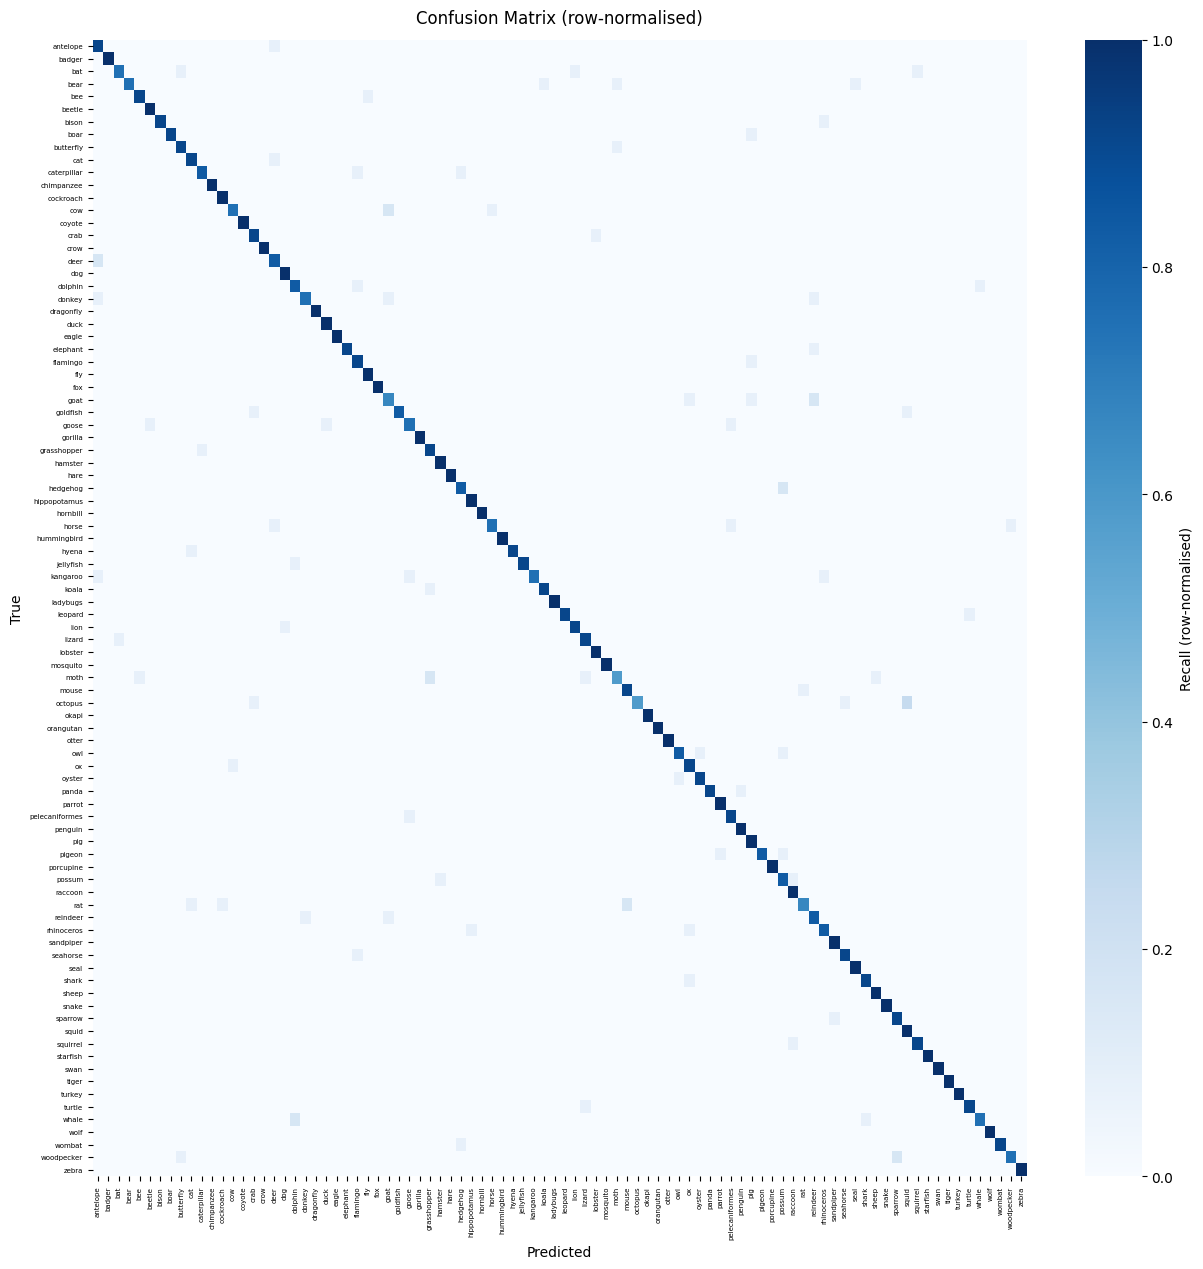

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred)

# Normalise rows so colour = recall per class (0–1)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)          # handle zero-row classes

n = len(class_names)
fig, ax = plt.subplots(figsize=(n * 0.12 + 2, n * 0.12 + 2))

sns.heatmap(
    cm_norm,
    ax=ax,
    cmap="Blues",
    annot=False,
    linewidths=0,
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Recall (row-normalised)"},
    vmin=0, vmax=1,
)

ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("True", fontsize=10)
ax.set_title("Confusion Matrix (row-normalised)", fontsize=12, pad=12)

# Thin tick labels
ax.tick_params(axis="both", labelsize=5)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [64]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(y_true, y_pred, target_names=class_names)

print("Classification Report:")
print(report)


Classification Report:
                precision    recall  f1-score   support

      antelope       0.73      0.92      0.81        12
        badger       1.00      1.00      1.00        12
           bat       0.90      0.75      0.82        12
          bear       1.00      0.75      0.86        12
           bee       0.92      0.92      0.92        12
        beetle       0.92      1.00      0.96        12
         bison       1.00      0.92      0.96        12
          boar       1.00      0.92      0.96        12
     butterfly       0.85      0.92      0.88        12
           cat       0.85      0.92      0.88        12
   caterpillar       0.91      0.83      0.87        12
    chimpanzee       1.00      1.00      1.00        12
     cockroach       0.92      1.00      0.96        12
           cow       0.90      0.75      0.82        12
        coyote       1.00      1.00      1.00        12
          crab       0.85      0.92      0.88        12
          crow       1.0